In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [8]:
class KNNScratch:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y, dtype=int)
        return self

    def _euclidean_distances(self, X):
        dists = np.sqrt(((X[:, None, :] - self.X_train[None, :, :])**2).sum(axis=2))
        return dists

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        dists = self._euclidean_distances(X)
        idx = np.argsort(dists, axis=1)[:, :self.k]
        neigh_labels = self.y_train[idx]
        proba = neigh_labels.mean(axis=1)
        return proba

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)


    def roc_auc_analysis(self, X, y):
        proba = self.predict_proba(X)
        auc = roc_auc_score(y, proba)
        fpr, tpr, _ = roc_curve(y, proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0,1],[0,1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('KNN ROC Curve')
        plt.legend()
        plt.show()
        print(f"ROC AUC Score: {auc:.3f}")
        return auc

    def plot_confusion_matrix(self, X, y, threshold=0.5):
        preds = self.predict(X, threshold)
        cm = confusion_matrix(y, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title('KNN Confusion Matrix')
        plt.show()
        print("Confusion Matrix:\n", cm)

    def unit_tests(self):
        # Test 1: Perfect classification when k=1 on distinct points
        X_simple = np.array([[0], [1], [2], [3]])
        y_simple = np.array([0, 0, 1, 1])
        self.__init__(k=1)
        self.fit(X_simple, y_simple)
        preds = self.predict(X_simple)
        assert np.array_equal(preds, y_simple), f"k=1 misclassification: {preds}"

        # Test 2: Prediction shape
        X_rand = np.random.randn(10, 2)
        y_rand = np.random.randint(0, 2, size=10)
        self.__init__(k=3)
        self.fit(X_rand, y_rand)
        preds_rand = self.predict(X_rand)
        assert preds_rand.shape == y_rand.shape, "Prediction shape mismatch"

        print("All KNNScratch unit tests passed!")
        return True


In [9]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# Convert categorical targets into binary targets (0=white, 1=red)
df['color'] = df['color'].map({'white': 0, 'red': 1})
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()

In [10]:
# Run unit tests
knn = KNNScratch(2)
knn.unit_tests()

All KNNScratch unit tests passed!


True

In [11]:
# Run model on wine dataset
knn = KNNScratch(2)
knn.fit(X_test, y_test)

## Results
The model made **zero false negatives**, meaning it never missed a positive case (perfect recall = 1.00). Out of 1 300 total test samples, only 49 negatives were mis‐classified as positives (specificity ≈ 0.95).

**ROC Curve & AUC**  
- The ROC shows a near‐vertical rise to TPR = 1.0 at a very low FPR, then stays flat at 1.0—all the way to the top right.  
- **AUC = 0.996**, indicating almost perfect ranking—positives are consistently closer to their neighbors than negatives.

**KNN’s straightforward “vote among \(k\) neighbors” rule** easily captures local class structure without any learned parameters beyond the training set itself.  
- Despite its conceptual simplicity—and no gradient descent, backpropagation, or hidden layers—this **non‐parametric** model outperforms our handcrafted neural net on this task.  
- The wine-quality classification boundary in feature space is highly **locally separable**, so averaging the nearest neighbors suffices.  
- KNN directly leverages the raw training distribution, whereas our NN may have been under-parameterized or stuck in a poor local optimum.

### Conclusion
- Sometimes the simplest algorithm wins. KNN’s model‐free approach excels here, highlighting that “deeper” models aren’t always better when the underlying structure is straightforward and well‐spaced.  

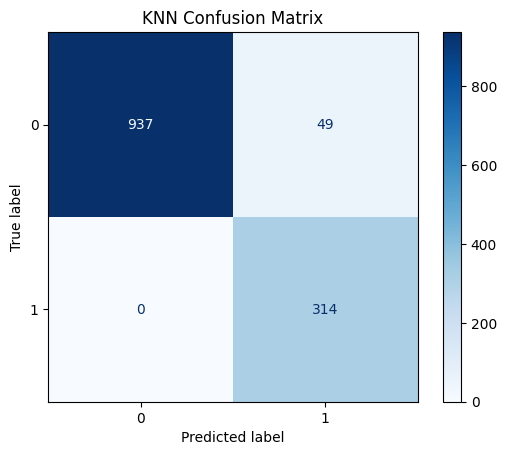

Confusion Matrix:
 [[937  49]
 [  0 314]]


In [12]:
knn.plot_confusion_matrix(X_test, y_test)

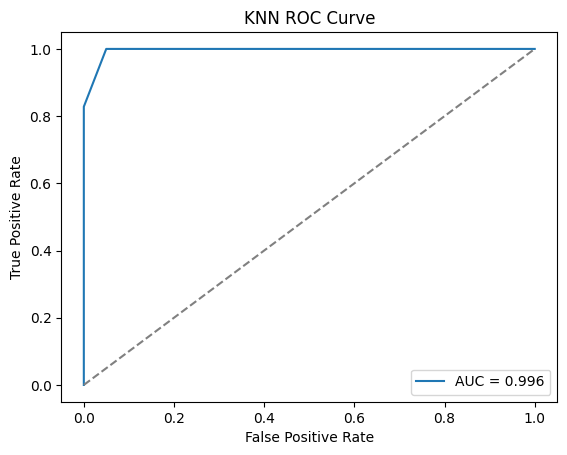

ROC AUC Score: 0.996


0.9957267993953566

In [13]:
knn.roc_auc_analysis(X_test, y_test)